In [2]:
import logging
import warnings
import time
import datetime
from dataclasses import dataclass
from typing import Tuple, List
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CountEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    cross_val_score,
    KFold,
    GroupKFold,
    StratifiedKFold,
    TimeSeriesSplit,
)
from sklearn.linear_model import (
    Lasso,
    LogisticRegression,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    roc_auc_score,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
import lightgbm as lgb
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
# shap.initjs()

#### 1. Download data from Don’tGetKicked competition.

kaggle competitions download -c DontGetKicked<br>
or direct download

##### 1.1 Read all the data

In [3]:
path: str = "data/DontGetKicked/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(
    path.format(name="training"), parse_dates=["PurchDate"]
)
test_df: pd.DataFrame = pd.read_csv(
    path.format(name="test"), parse_dates=["PurchDate"]
)

##### 1.2 Drop columns with N/A > 50%

In [4]:
NA_threshold = 0.5
NA_percent = train_df.isnull().mean()
to_drop = NA_percent[NA_percent >= NA_threshold].index
train_df_wo_na = train_df.drop(columns=to_drop)

##### 1.3 Simple impute N/A for other columns and scale numeric

In [5]:
target = "IsBadBuy"
datetime_col = "PurchDate"
numeric = (
    train_df_wo_na.drop(target, axis=1)
    .select_dtypes(exclude=["object", "datetime"])
    .columns
)

categories = train_df_wo_na.select_dtypes(include="object").columns

numeric_pipeline = Pipeline(
    [("num_imp", SimpleImputer(strategy="median")), ("st_scaler", StandardScaler()),]
)

categories_pipeline = Pipeline(
    [("cat_imp", SimpleImputer(strategy="constant", fill_value="unknown")),]
)

col_tr = ColumnTransformer(
    transformers=[
        ('num_pipeline', numeric_pipeline, numeric),
        ('cat_pipeline', categories_pipeline, categories)
    ],
    remainder="drop",
)
train_df_tform_arr = col_tr.fit_transform(train_df_wo_na)

train_df_tform = pd.DataFrame(train_df_tform_arr)
train_df_tform.columns = numeric.to_list() + categories.to_list()
# add target and datetime col to final df
train_df_tform[datetime_col] = train_df_wo_na[datetime_col]
train_df_tform[target] = train_df_wo_na[target]

#### 2. Design the train/validation/test split. <br>Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. <br>Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [6]:
# all funcs from ML3
def split_by_date(
    X: pd.DataFrame,
    date_split: datetime.datetime,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    info: pd.Series = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in info.values]
    is_date_in_df = any(date_in_df)
    if not is_date_in_df:
        raise ValueError("No date col in df")

    # finds first entrance of datetype col
    date_col = info.index[date_in_df.index(True)]
    # sorts initial df to make proper split
    X = X.sort_values(by=date_col)
    X_train = X.loc[X[date_col] <= date_split]
    X_test = X.loc[X[date_col] > date_split]

    time_condition = X_train[date_col].max() < X_test[date_col].max()
    if not time_condition:
        raise ValueError("Split date cant provide proper split")

    return X_train, X_test


def validation_split_by_date(
    X: pd.DataFrame,
    validation_date: datetime.datetime,
    test_date: datetime.datetime,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    X_train, X_test = split_by_date(X, date_split=test_date)
    X_train, X_valid = split_by_date(X_train, date_split=validation_date)
    return X_train, X_valid, X_test


def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=" ") for x in df_list]

In [7]:
validation_date = datetime.datetime(year=2009, month=9, day=13)
test_date = datetime.datetime(year=2010, month=5, day=13)
X_train, X_valid, X_test = validation_split_by_date(
    X=train_df_tform, validation_date=validation_date, test_date=test_date
)
check_split(df_list=[X_train, X_valid, X_test], df_initial=train_df_tform)

True
0.33 0.34 0.33 

#### 3. Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables. Be careful with data leakage (fit Encoder to training and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html

In [8]:
cat_to_onehot_enc: list = []
cat_to_count_enc: list = []
for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_count_enc.append(category)

In [9]:
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit_transform(X_train[cat_to_onehot_enc])
cat_one_hot_enc = pd.DataFrame(
    cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
)

count_enc = CountEncoder(normalize=True, min_group_size=15)
cat_count_enc = count_enc.fit_transform(X_train[cat_to_count_enc])

X_train_ = pd.concat(
    [
        X_train[numeric].reset_index(drop=True),
        cat_one_hot_enc.reset_index(drop=True),
        cat_count_enc.reset_index(drop=True),
        X_train[target].reset_index(drop=True)
    ],
    axis=1,
)

In [10]:
df_transformed = [pd.DataFrame(), pd.DataFrame()]

for num, df in enumerate([X_valid, X_test]):
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out())
    cat_count_enc = count_enc.transform(df[cat_to_count_enc])
    df_transformed[num] = pd.concat(
        [
            df[numeric].reset_index(drop=True), 
            cat_one_hot_enc.reset_index(drop=True), 
            cat_count_enc.reset_index(drop=True),
            df[target].reset_index(drop=True)
        ], 
        axis=1
    )

X_valid_, X_test_ = df_transformed

In [11]:
y_train_ = X_train_["IsBadBuy"]
X_train_ = X_train_.drop("IsBadBuy", axis=1)
y_valid_ = X_valid_["IsBadBuy"]
X_valid_ = X_valid_.drop("IsBadBuy", axis=1)
y_test_ = X_test_["IsBadBuy"]
X_test_ = X_test_.drop("IsBadBuy", axis=1)

#### 4. Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset. <br>The dependent variable (IsBadBuy) is binary. Don't forget to normalize your datasets before training your models.

You must get at least 0.15 Gini score (the best of all three). Which algorithm performs better? And why?


In [12]:
out: pd.DataFrame = pd.DataFrame({'model': [], 'Gini': []})

for model in LogisticRegression(), GaussianNB(), KNeighborsClassifier():
    model.fit(X=X_train_, y=y_train_)
    # by [:,1] we get pos observation
    y_pred = model.predict_proba(X=X_valid_)[:, 1]
    # using 2*ROC AUC - 1 approach
    out.loc[len(out)] = {
        'model': model, 
        'Gini':  round(2 * roc_auc_score(y_true=y_valid_, y_score=y_pred) - 1, 4),
    }

display(out.sort_values(by='Gini', ascending=False).reset_index(drop=True))

,model,Gini
0,GaussianNB(),0.4243
1,LogisticRegression(),0.4218
2,KNeighborsClassifier(),0.2249


Difference between GaussianNB and LogisticRegression isn't significat so they are the best algoes.<br>
Why? Beacause of preprocessing: StandardScaler and CountEncoder is suited (robust) for these algos.<br>
For KNN our preprocessing is not suitable: sensitive for sparsity after OneHotEncoder<br>
(for GaussianNB and Logistic seems not)

#### 5. Implement Gini score calculation. <br>You can use the 2*ROC AUC - 1 approach, so you need to implement the ROC AUC calculation. <br>Check if your metric is approximately equal to abs(2*sklearn.metrics.roc_auc_score - 1).

In [13]:
def plot_roc(false_pos_rate, true_pos_rate) -> None:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(false_pos_rate, true_pos_rate, label='ROC curve')
    ax.plot([0, 1], [0, 1], linestyle='--', c='gray')

    ax.set_title('ROC cruve plot', fontsize=16)
    ax.set_xlabel('FP rate', fontsize=16)
    ax.set_ylabel('TP rate', fontsize=16)
    ax.legend()
    ax.grid()

In [14]:
def roc_auc_np(y_true, y_score):
    '''
    ROC AUC stands for Receiver Operating Characteristic Area Under the Curve
    np-like
    '''
    sorted_idx = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_idx]
    
    True_Pos = np.cumsum(y_true_sorted)
    False_Pos = np.cumsum(1 - y_true_sorted)

    # normalize
    true_pos_rate = True_Pos / True_Pos[-1] if True_Pos[-1] > 0 \
        else np.zeros_like(True_Pos)
    false_pos_rate = False_Pos / False_Pos[-1] if False_Pos[-1] > 0 \
        else np.zeros_like(False_Pos)
    
    # add start point
    true_pos_rate = np.r_[0, true_pos_rate]
    false_pos_rate = np.r_[0, false_pos_rate]
    
    auc_score = 0
    for i in range(1, len(false_pos_rate)):
        auc_score += (
            (false_pos_rate[i] - false_pos_rate[i-1]) * 
            (true_pos_rate[i] + true_pos_rate[i-1]) / 2
        )

    return auc_score, (false_pos_rate, true_pos_rate)

In [15]:
def roc_auc(y_true, y_score):
    '''
    ROC AUC stands for Receiver Operating Characteristic Area Under the Curve
    '''
    sorted_idx = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_idx]  
    true_pos_rate, false_pos_rate = [0], [0]
    True_Pos, False_Pos = 0, 0
    Pos = sum(y_true)
    Neg = len(y_true) - Pos

    for i in range(len(y_true_sorted)):
        if y_true_sorted[i]:
            True_Pos += 1 
        else:
            False_Pos += 1 
        
        true_pos_rate.append(True_Pos / Pos)   
        false_pos_rate.append(False_Pos / Neg)  

    # or use np.trapz(true_pos_rate, false_pos_rate)
    auc_score = 0
    for i in range(1, len(false_pos_rate)):
        auc_score += (
            (false_pos_rate[i] - false_pos_rate[i-1]) * 
            (true_pos_rate[i] + true_pos_rate[i-1]) / 2
        )

    return auc_score, (false_pos_rate, true_pos_rate)


def gini_score(y_true, y_score):
    '''using 2*ROC AUC - 1 approach'''
    return 2 * roc_auc(y_true=y_true, y_score=y_score)[0] - 1

,model,roc_auc,Gini
0,my,0.623393,0.2468
1,sklearn,0.612453,0.2249


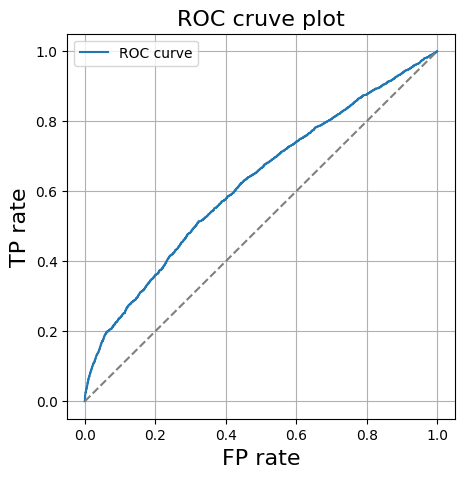

In [16]:
# check
out: pd.DataFrame = pd.DataFrame({'model': [], 'roc_auc': [], 'Gini': []})

out.loc[len(out)] = {
    'model': 'my',
    'roc_auc': roc_auc(y_true=y_valid_.values, y_score=y_pred)[0], 
    'Gini':  round(gini_score(y_true=y_valid_.values, y_score=y_pred), 4),
}

out.loc[len(out)] = {
    'model': 'sklearn',
    'roc_auc': roc_auc_score(y_true=y_valid_, y_score=y_pred), 
    'Gini':  round(2 * roc_auc_score(y_true=y_valid_, y_score=y_pred) - 1, 4),
}

display(out)
plot_roc(*roc_auc(y_true=y_valid_.values, y_score=y_pred)[1])

![pic5](../misc/images/precision.png)

#### 6. Implement your own versions of LogisticRegression, KNN and NaiveBayes classifiers.<br> For LogisticRegression compute gradients with respect to the loss and use stochastic gradient descent. <br> Can you reproduce the results from step 4?

Guidance for this task: Your model must be represented by class with methods fit, predict (predict_proba with 0.5 threshold), predict_proba.<br>
For LR moder, compute the loss gradient with respect to parameters w and parameter b in the fit function.<br>
Use a simple SGD approach to estimate optimal values of parameters.

In [ ]:
@dataclass
class LogisticRegression_SGD:
    '''Stochastic Gradient Descent for Logistic regression'''

    fit_intercept: bool = True
    learning_rate: float = 0.01
    batch_size: int = 10_000
    epoch: int = 100
    tolerance: float = 1e-04
    l2_penalty: float = 1.0

    def predict_proba(self, X):
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        z = np.array(X @ self.weights, dtype=np.float32)
        sigmoid = 1 / (1 + np.exp(-z)) 
        return sigmoid

    def predict(self, X,  threshold=0.5):
        '''eq to predict_proba with 0.5 threshold'''
        threshold = 0.5
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        proba = self.predict_proba(X)
        return proba > threshold

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict_proba(X) - y
        dw = 1 / n_samples * X.T @ err

        return dw

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent

    def loss(self, X, y):
        n_samples = X.shape[0]
        prob = self.predict_proba(X)
        cost = - 1 / n_samples * np.sum(
            y * np.log(prob) + 
            (1 - y) * np.log(1 - prob)
        )
        return cost

    def fit(self, X, y):
        # shuffle X, y
        X = X.sample(frac=1, random_state=21)
        y = y[X.index]
        # add ones if include intercept else 0 to exclude it
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        weights_hist, loss_hist = [self.weights.copy()], [self.loss(X, y)]
        self.convergence, self.iterations = 0, 0

        for _ in range(self.epoch):
            for B in range(0, n_samples, self.batch_size):
                self.iterations += 1
                X_batch = X.iloc[B : B + self.batch_size]
                y_batch = y.iloc[B : B + self.batch_size]
                dw = self.descent(X_batch, y_batch)
                self.refresh_weights(descent=dw)
                # w/o copy weights ptr/link will be added
                weights_hist.append(self.weights.copy())
                loss_hist.append(self.loss(X_batch, y_batch))
                # using (np.abs(weights_hist[-1] - weights_hist[-2]) < self.tolerance).all()
                # is less stable; could use mse_hist same as weight_hist

                if np.linalg.norm(weights_hist[-1] - weights_hist[-2]) < self.tolerance:
                    # print(weights_hist[-1] - weights_hist[-2])
                    self.convergence = 1
                    break
            if self.convergence:
                break

        self.weights_hist = weights_hist
        self.mse_hist = loss_hist
        *self.coef_, self.intercept_ = self.weights

In [88]:
out: pd.DataFrame = pd.DataFrame({'model': [], 'roc_auc': [], 'Gini': []})

for model in  [LogisticRegression_SGD(learning_rate=0.1, epoch=600)]:
# for model in LogisticRegression(), GaussianNB(), KNeighborsClassifier(), LogisticRegression_SGD():
    model.fit(X=X_train_, y=y_train_)
    # by [:,1] we get pos observation
    y_pred = model.predict_proba(X=X_valid_)
    # y_pred = model.predict_proba(X=X_valid_)[:, 1]
    # using 2*ROC AUC - 1 approach
    print(y_pred)
    out.loc[len(out)] = {
        'model': model, 
        'roc_auc': roc_auc_score(y_true=y_valid_, y_score=y_pred), 
        'Gini':  round(2 * roc_auc_score(y_true=y_valid_, y_score=y_pred) - 1, 4),
    }

# display(out.sort_values(by='Gini', ascending=False).reset_index(drop=True))
out

[0.07127524 0.1126494  0.12101066 ... 0.12446507 0.13024007 0.11989028]


,model,roc_auc,Gini
0,"LogisticRegression_SGD(fit_intercept=True, lea...",0.712251,0.4245


In [82]:
@dataclass
class KNN:
    '''K Neighbors Classifier'''

In [83]:
@dataclass
class NaiveBayes:
    '''Naive Bayes method'''

#### 7. Try to create non-linear features, for example:

fractions: feature1/feature2
<br/>groupby features: `df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())`
<br/><br/>
Add new features to your pipeline, repeat step 4. Did you manage to increase your Gini score (you should!)?

#### 8. Determine the best features for the problem using the coefficients of the logistic model. <br>Try to eliminate useless features by hand and by L1 regularization. Which approach is better in terms of Gini score?

#### 9. Select your best model (algorithm + feature set) and tweak its hyperparameters to increase the Gini score on the validation dataset. <br>Which hyperparameters have the most impact?

#### 10. Check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini. Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitted or not? Explain.

#### 11. Implement calculation of Recall, Precision, F1 score and AUC PR metrics. <br>Compare your algorithms on the test dataset using AUC PR metric.

#### 12. Which hard label metric do you prefer for the task of detecting "lemon" cars?